In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
len(df)

6362620

# ¡¡¡6,362,620 OBSERVACIONES!!!

## 1. Exploración de datos

In [5]:
# Información general del dataset
print(f"Dimensiones: {df.shape}")
print(f"\n--- Tipos de datos ---")
print(df.dtypes)
print(f"\n--- Valores nulos ---")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

Dimensiones: (6362620, 11)

--- Tipos de datos ---
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

--- Valores nulos ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total nulos: 0


In [6]:
# Distribución de la variable objetivo
print("--- Distribución de isFraud ---")
print(df['isFraud'].value_counts())
print(f"\nPorcentaje de fraude: {df['isFraud'].mean() * 100:.4f}%")

# Tipos de transacción
print("\n--- Tipos de transacción ---")
print(df['type'].value_counts())

--- Distribución de isFraud ---
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Porcentaje de fraude: 0.1291%

--- Tipos de transacción ---
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [7]:
# Fraude por tipo de transacción
print("--- Fraude por tipo de transacción ---")
print(df.groupby('type')['isFraud'].sum())

--- Fraude por tipo de transacción ---
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


## 2. Preprocesamiento de datos

In [8]:
# Eliminar columnas que no aportan al modelo:
# - nameOrig y nameDest: son identificadores únicos, no features predictivas
# - isFlaggedFraud: es una etiqueta del sistema, no una característica real
df_clean = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

# Codificar la variable categórica 'type' con One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

print(f"Columnas después del preprocesamiento:")
print(df_clean.columns.tolist())
print(f"\nDimensiones: {df_clean.shape}")
df_clean.head()

Columnas después del preprocesamiento:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Dimensiones: (6362620, 11)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,True,False


## 3. Separar features (X) y target (y)

In [9]:
# Separar features y target
X = df_clean.drop(columns=['isFraud'])
y = df_clean['isFraud']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Distribución del target:\n{y.value_counts()}")

Shape de X: (6362620, 10)
Shape de y: (6362620,)
Distribución del target:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


## 4. Train/Test Split

In [10]:
# Dividir en 80% entrenamiento y 20% prueba
# stratify=y mantiene la proporción de fraude en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print(f"\nProporción de fraude en train: {y_train.mean()*100:.4f}%")
print(f"Proporción de fraude en test:  {y_test.mean()*100:.4f}%")

Entrenamiento: 5090096 muestras
Prueba: 1272524 muestras

Proporción de fraude en train: 0.1291%
Proporción de fraude en test:  0.1291%


## 5. Escalado de características (StandardScaler)

In [11]:
# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalado completado.")

Escalado completado.


## 6. Entrenamiento del modelo de Regresión Logística

In [12]:
# Entrenar el modelo de regresión logística
# class_weight='balanced' ajusta los pesos para compensar el desbalance de clases
modelo = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 7. Evaluación del Modelo

In [13]:
# Realizar predicciones
y_pred = modelo.predict(X_test_scaled)

# Matriz de confusión
print("=" * 50)
print("        MATRIZ DE CONFUSIÓN")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
print(f"  Verdaderos Negativos (TN): {cm[0][0]:>10,}")
print(f"  Falsos Positivos     (FP): {cm[0][1]:>10,}")
print(f"  Falsos Negativos     (FN): {cm[1][0]:>10,}")
print(f"  Verdaderos Positivos (TP): {cm[1][1]:>10,}")

# Reporte de clasificación
print("\n" + "=" * 50)
print("    EVALUACIÓN FINAL DEL MODELO")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))

        MATRIZ DE CONFUSIÓN
  Verdaderos Negativos (TN):  1,206,228
  Falsos Positivos     (FP):     64,653
  Falsos Negativos     (FN):         64
  Verdaderos Positivos (TP):      1,579

    EVALUACIÓN FINAL DEL MODELO
              precision    recall  f1-score   support

    Legítima       1.00      0.95      0.97   1270881
      Fraude       0.02      0.96      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



## 8. Visualización: Matriz de Confusión

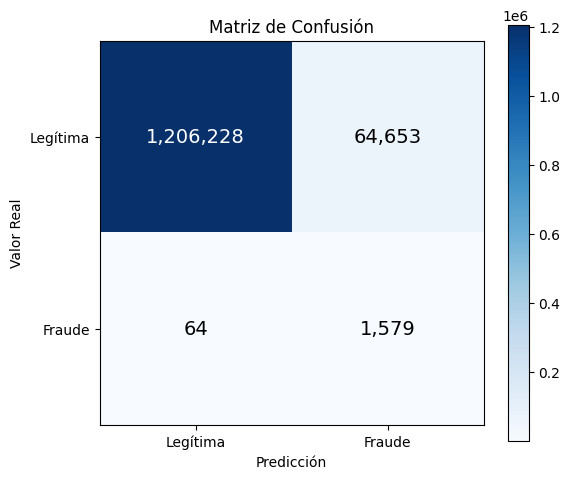

In [14]:
# Visualizar la matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Etiquetas
labels = ['Legítima', 'Fraude']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
ax.set_title('Matriz de Confusión')

# Mostrar valores en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i][j]:,}', ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black', fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()